In [1]:
import numpy as np
import imageio
import os
import time
import matplotlib.pyplot as plt
from dask import delayed, compute
import dask.bag as db
from dask.distributed import Client

In [2]:
def readImg(path):
    # Read an image file and convert to numpy array
    # Using uint8 datatype for standard 8-bit per channel images
    img = imageio.imread(path)
    im = np.array(img, dtype='uint8')
    return im

def writeImg(path, buf):
    # Write the processed image array to a file
    imageio.imwrite(path, buf)
    
def display_images(original, filtered, title1="Noisy Image", title2="Filtered Image"):
    # Display original and filtered images side by side for visual comparison
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(title1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(filtered)
    plt.title(title2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [3]:
@delayed
def part_median_filter(local_data):
    # Extract data for this partition
    part_id = int(local_data[0])
    first = int(local_data[1])
    end = int(local_data[2])
    buf = local_data[3]
    
    # Get dimensions of the full image
    nx = buf.shape[0]
    ny = buf.shape[1]
    
    # Check if image is color (RGB) or grayscale
    if len(buf.shape) > 2:
        # Handle color image (RGB)
        nz = buf.shape[2]
        new_buf = np.zeros((end - first, ny, nz), dtype='uint8')
        
        # Apply median filter to each pixel in this partition
        for i in range(first, end):
            for j in range(ny):
                for c in range(nz):  # Process each color channel
                    # Collect the 3x3 neighborhood
                    neighbors = []
                    for di in range(-1, 2):
                        for dj in range(-1, 2):
                            # Handle boundary conditions with min/max
                            ni = min(max(i + di, 0), nx - 1)
                            nj = min(max(j + dj, 0), ny - 1)
                            neighbors.append(buf[ni, nj, c])
                    
                    # Replace with median value
                    new_buf[i - first, j, c] = np.median(neighbors)
    else:
        # Handle grayscale image
        new_buf = np.zeros((end - first, ny), dtype='uint8')
        
        for i in range(first, end):
            for j in range(ny):
                neighbors = []
                for di in range(-1, 2):
                    for dj in range(-1, 2):
                        ni = min(max(i + di, 0), nx - 1)
                        nj = min(max(j + dj, 0), ny - 1)
                        neighbors.append(buf[ni, nj])
                        
                new_buf[i - first, j] = np.median(neighbors)
    
    # Return partition ID and filtered partition
    return part_id, new_buf

In [4]:
def main():
    # Set up paths
    data_dir = '.'  # Current directory, adjust as needed
    file = os.path.join(data_dir, 'lena_noisy.jpg')
    
    # Load the image
    img_buf = readImg(file)
    print('Image shape:', img_buf.shape)
    
    # Get dimensions
    if len(img_buf.shape) > 2:
        nx, ny, nz = img_buf.shape
    else:
        nx, ny = img_buf.shape
    
    # Split image into partitions for parallel processing
    nb_partitions = 8  # Number of partitions
    print(f"Splitting image into {nb_partitions} partitions")
    
    # Create list of partitions
    data = []
    begin = 0
    block_size = nx // nb_partitions  # Integer division for even splits
    
    for ip in range(nb_partitions):
        end = min(begin + block_size, nx)
        data.append([ip, begin, end, img_buf])
        begin = end
    
    # Initialize Dask client for parallel computing
    print("Starting Dask client...")
    client = Client()
    print(f"Dashboard link: {client.dashboard_link}")
    
    # Apply median filter in parallel using Dask
    print("Starting parallel median filter computation...")
    start_time = time.time()
    
    # Process each partition with delayed function
    results = [part_median_filter(part_data) for part_data in data]
    # Compute results in parallel
    result_data = compute(*results)
    
    end_time = time.time()
    print(f"Parallel processing completed in {end_time - start_time:.4f} seconds")
    
    # Initialize output image buffer
    if len(img_buf.shape) > 2:
        new_img_buf = np.zeros((nx, ny, nz), dtype='uint8')
    else:
        new_img_buf = np.zeros((nx, ny), dtype='uint8')
    
    # Assemble final image from processed partitions
    # Sort to ensure correct order regardless of execution order
    for part_id, part_buf in sorted(result_data, key=lambda x: x[0]):
        start_row = data[part_id][1]
        end_row = data[part_id][2]
        if len(img_buf.shape) > 2:
            new_img_buf[start_row:end_row, :, :] = part_buf
        else:
            new_img_buf[start_row:end_row, :] = part_buf
    
    # Save filtered image
    print('Creating filtered image file...')
    filter_file = os.path.join(data_dir, 'lena_filter.jpg')
    writeImg(filter_file, new_img_buf)
    print(f"Filtered image saved as {filter_file}")
    
    # Close Dask client
    client.close()
    
    # Return original and filtered images for display
    return img_buf, new_img_buf

In [5]:
def calculate_noise_reduction(original, filtered):
    # Calculate standard deviation as a measure of noise
    # Lower standard deviation typically indicates less noise
    original_std = np.std(original)
    filtered_std = np.std(filtered)
    
    # Calculate percentage reduction in noise
    reduction_percent = ((original_std - filtered_std) / original_std) * 100
    return original_std, filtered_std, reduction_percent

/tmp/ipykernel_28607/4003857745.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


Image shape: (128, 128, 3)
Splitting image into 8 partitions
Starting Dask client...
Dashboard link: http://127.0.0.1:8787/status
Starting parallel median filter computation...
Parallel processing completed in 0.8070 seconds
Creating filtered image file...
Filtered image saved as ./lena_filter.jpg


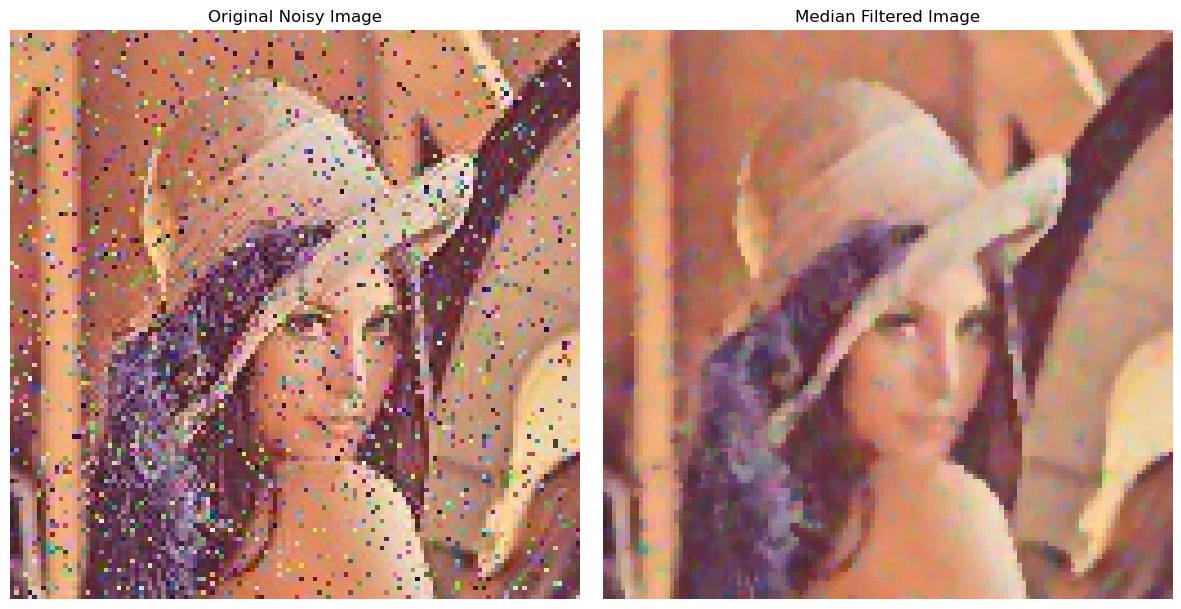

Red channel - Original std: 50.36, Filtered std: 45.54, Noise reduction: 9.59%
Green channel - Original std: 48.60, Filtered std: 44.08, Noise reduction: 9.30%
Blue channel - Original std: 40.35, Filtered std: 32.48, Noise reduction: 19.50%


In [6]:
# Run the main processing function
original_img, filtered_img = main()

# Display both images side by side
display_images(original_img, filtered_img, "Original Noisy Image", "Median Filtered Image")

# Calculate and display noise reduction metrics
if len(original_img.shape) > 2:
    # For color images, calculate metrics per channel
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        orig_std, filt_std, reduction = calculate_noise_reduction(
            original_img[:,:,i], filtered_img[:,:,i])
        print(f"{channels[i]} channel - Original std: {orig_std:.2f}, "
              f"Filtered std: {filt_std:.2f}, Noise reduction: {reduction:.2f}%")
else:
    # For grayscale images
    orig_std, filt_std, reduction = calculate_noise_reduction(original_img, filtered_img)
    print(f"Original std: {orig_std:.2f}, Filtered std: {filt_std:.2f}, "
          f"Noise reduction: {reduction:.2f}%")